# Practica 04: Analisis de Datos Exploratorios con Python y jupiter Notebook en un Dataset de productos de Amazon Store

**Programa de Estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analitica de Datos para Negocios Digitales  \
**Docente:** M.T.I Marco A. Ramirez Hernandez \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparacion de los Datos 

**Nombre:** Karol Janeeth Gonzalez Vargas\
**Matricula:** 230323  \
**Grado y grupo:** 9°A IEVND 

<div style="background: linear-gradient(135deg, #288BC7 0%, #232F3E 100%);
padding: 30px; border-radius: 15px; text-align: center;
margin-bottom: 20px;">

<h1 style="color: white; font-size: 2.2em; margin: 0;">
🛒 Productos de Amazon Store – Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">
Predicción de Precios · Análisis de Categorías · Ingeniería de Funcionalidades · Comparación de Modelos
</p>

</div>

---

## 📋 Tabla de Contenidos 
| # | Seccion | Descripcion |
|---|---|---|
| 1 | [Instalaciones & Carga de Datos](#s1) | Librerías, carga del CSV, primeros comandos de estructura |
| 2 | [Diccionario de Datos](#s2) | Explicaciondel contenido de columnas y calcular que 1% de datos faltantes |
| 3 | [Limpieza de Datos](#s3) | Aplicacion de metodos basicos de limpieza(eliminacion duplicadas, agrupacion, datos nulos) |
| 4 | [Ingenieria de Caracteristicas](#s4) | Características de texto, indicadores de categoría, niveles de precios |
| 5 | [Análisis univariado](#s5) | Distribuciones, valores atipicos, pruebas de normalidad|
| 6 | [Análisis de categorías ](#s6) | Top categorias,precio por categoria|
| 7 | [Análisis de disponibilidad](#s7) |Patrones delestado de stock |
| 8 | [Análisis de correlación y bivariado](#s8) | Heatmap,grafico de dispersion |


## 1. Instalaciones & Carga de Datos 🔧 <a id='s1'></a> 

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0; color:#0066cc;">

<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>

<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>

<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in

</div>

In [94]:
# =============================================
# SECTION 1 - Setup & Data  Loading
# =============================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as ptl
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy.stats import shapiro

#ML - Machine Learning - Entrenamiento de modelos matematicos para predecir en este caso precios 
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f'✅ Pandas : {pd.__version__}')
print(f'✅ NumPy : {np.__version__}')
print('✅ Todas las librerías cargaron con éxito!')


✅ Pandas : 2.3.3
✅ NumPy : 2.3.5
✅ Todas las librerías cargaron con éxito!


In [95]:
# Load dataset
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f'📦 Shape: {df_raw.shape}')
print(f'📋 Columns: {df_raw.columns.tolist()}')

df_raw.head(3)

📦 Shape: (1448, 17)
📋 Columns: ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de Datos del Data Frame   <a id='s2'></a> 

In [96]:
# Colum dictionary 
col_info = {
    'rl'               :'URL del producto en Amazon.in',
    'asin'             :'Numero Estandarizado de Indentificacion por Amazon(unique ID)',
    'name'             :'Nombre o Titulo del Producto',
    'overview'         :'Breve reseña del Producto(mayoria vacio [])',
    'price'            :'Precio como string (e.g "1,600.00")',
    'currency'         :'Codigo de Divisa(Todas en INR)',
    'availability'     :'Texto del Satatus del stock(Inventario)',
    'brand'            :'Nombre de la Marca/Autor',
    'about_item'       :'Detalles/Especificaciones(mayoria faltante)',
    'img_source'       :'URLs de Imagenes del producto',
    'description'      :'Descripcion detallada y completa(mayoria faltante)',
    'specifications'   :'Especificaciones Tecnicas',
    'primary_category' :'Categoria Principal(Libros, Kindle, Deportes...)',
    'category_1'       :'Subcategoria de Nivel 1',
    'category_2'       :'Subcategoria de Nivel 2)',
    'category_3'       :'Subcategoria de Nivel 3',
    'breadcrumbs'      :'Ruta de Categorias',
}
print('📖 Diccionario por columnas:')

for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(
        f' {col:20s} |' 
        f' {desc[:45]:45s} |'
        f' Missing: {missing_pct:.0f}%'
    )


📖 Diccionario por columnas:
 rl                   | URL del producto en Amazon.in                 | Missing: 0%
 asin                 | Numero Estandarizado de Indentificacion por A | Missing: 0%
 name                 | Nombre o Titulo del Producto                  | Missing: 1%
 overview             | Breve reseña del Producto(mayoria vacio [])   | Missing: 0%
 price                | Precio como string (e.g "1,600.00")           | Missing: 24%
 currency             | Codigo de Divisa(Todas en INR)                | Missing: 24%
 availability         | Texto del Satatus del stock(Inventario)       | Missing: 33%
 brand                | Nombre de la Marca/Autor                      | Missing: 1%
 about_item           | Detalles/Especificaciones(mayoria faltante)   | Missing: 92%
 img_source           | URLs de Imagenes del producto                 | Missing: 1%
 description          | Descripcion detallada y completa(mayoria falt | Missing: 92%
 specifications       | Especificaciones Te

## 3.Limpieza de Datos <a id='s3'></a> 

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parseas el precio strings como "1,600.00" → float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [97]:
# ============================================================
# SECTION 3 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,096 / 1,448 products
✅ Duplicate ASINs: 8
✅ Availability categories: {'In Stock': 609, 'Unknown': 482, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 80, 'Other': 25, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


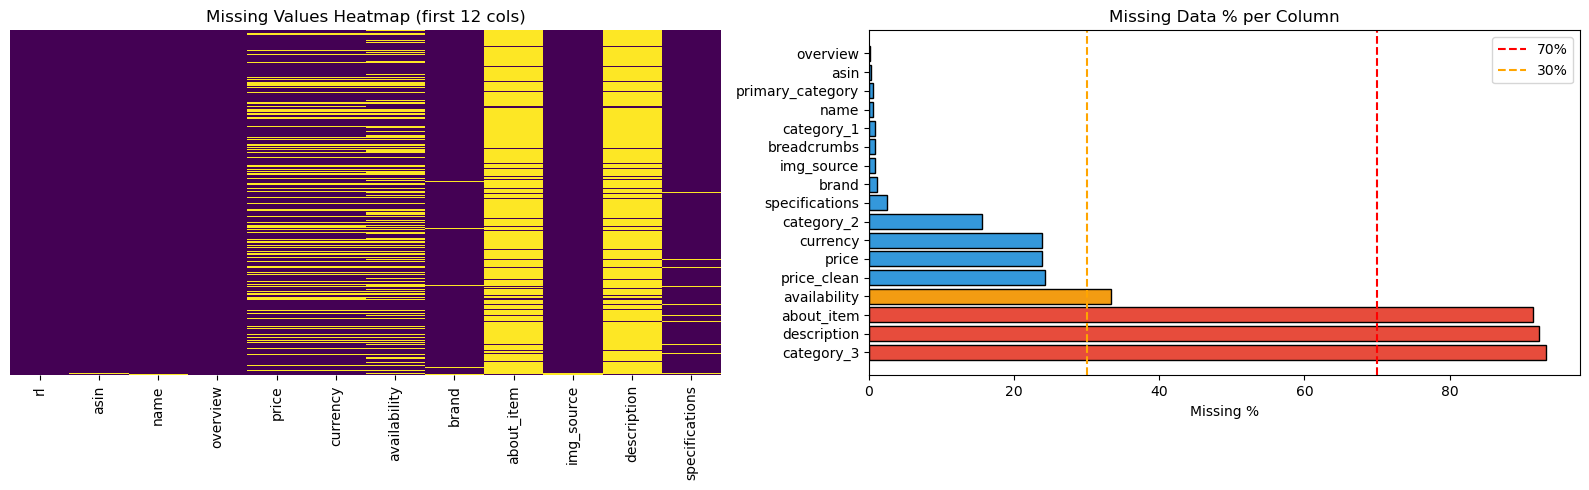

                  Missing Count  Missing Pct
category_3                 1351         93.3
description                1336         92.3
about_item                 1325         91.5
availability                482         33.3
price_clean                 352         24.3
price                       346         23.9
currency                    346         23.9
category_2                  226         15.6
specifications               36          2.5
brand                        16          1.1
img_source                   11          0.8
breadcrumbs                  12          0.8
category_1                   11          0.8
name                          8          0.6
primary_category              7          0.5
asin                          4          0.3
overview                      2          0.1


In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    df[df.columns[:12]].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis',
    ax=axes[0]
)
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]

if not mv.empty:
    colors_mv = [
        '#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
        for v in mv['Missing Pct']
    ]

    axes[1].barh(
        mv.index,
        mv['Missing Pct'],
        color=colors_mv,
        edgecolor='black'
    )
    axes[1].axvline(70, color='red', linestyle='--', label='70%')
    axes[1].axvline(30, color='orange', linestyle='--', label='30%')
    axes[1].legend()

axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Data % per Column')

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4.Ingenieria de Caracteristicas (Feature Engineering) <a id='s4'></a> 

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ea60; border-radius:5px; color: #0066cc;">
<b>Ejemplo Cotidiano:</b>Un agente inmobiliario no solo utiliza ls metros cuadrados bruts, si no que tambien considera la ubicacion, la antiguedad y el estado. nosotros hacemos lo mismo: extraemos informacion mas valiosa del texto sin procesar y las categorias....
</div>

In [99]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total features engineered: {len(df.columns)}')
print('\nPrice tier distribution:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total features engineered: 39

Price tier distribution:
price_tier
1_budget     105
2_low        285
3_mid        320
4_premium    260
5_luxury     126
Unknown      352


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5.Análisis univariado (Univariate Analysis) <a id='s5'></a> 

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Cómo es la distribución de precios? ¿Hay valores atípicos? ¿Los datos están sesgados?
</div>

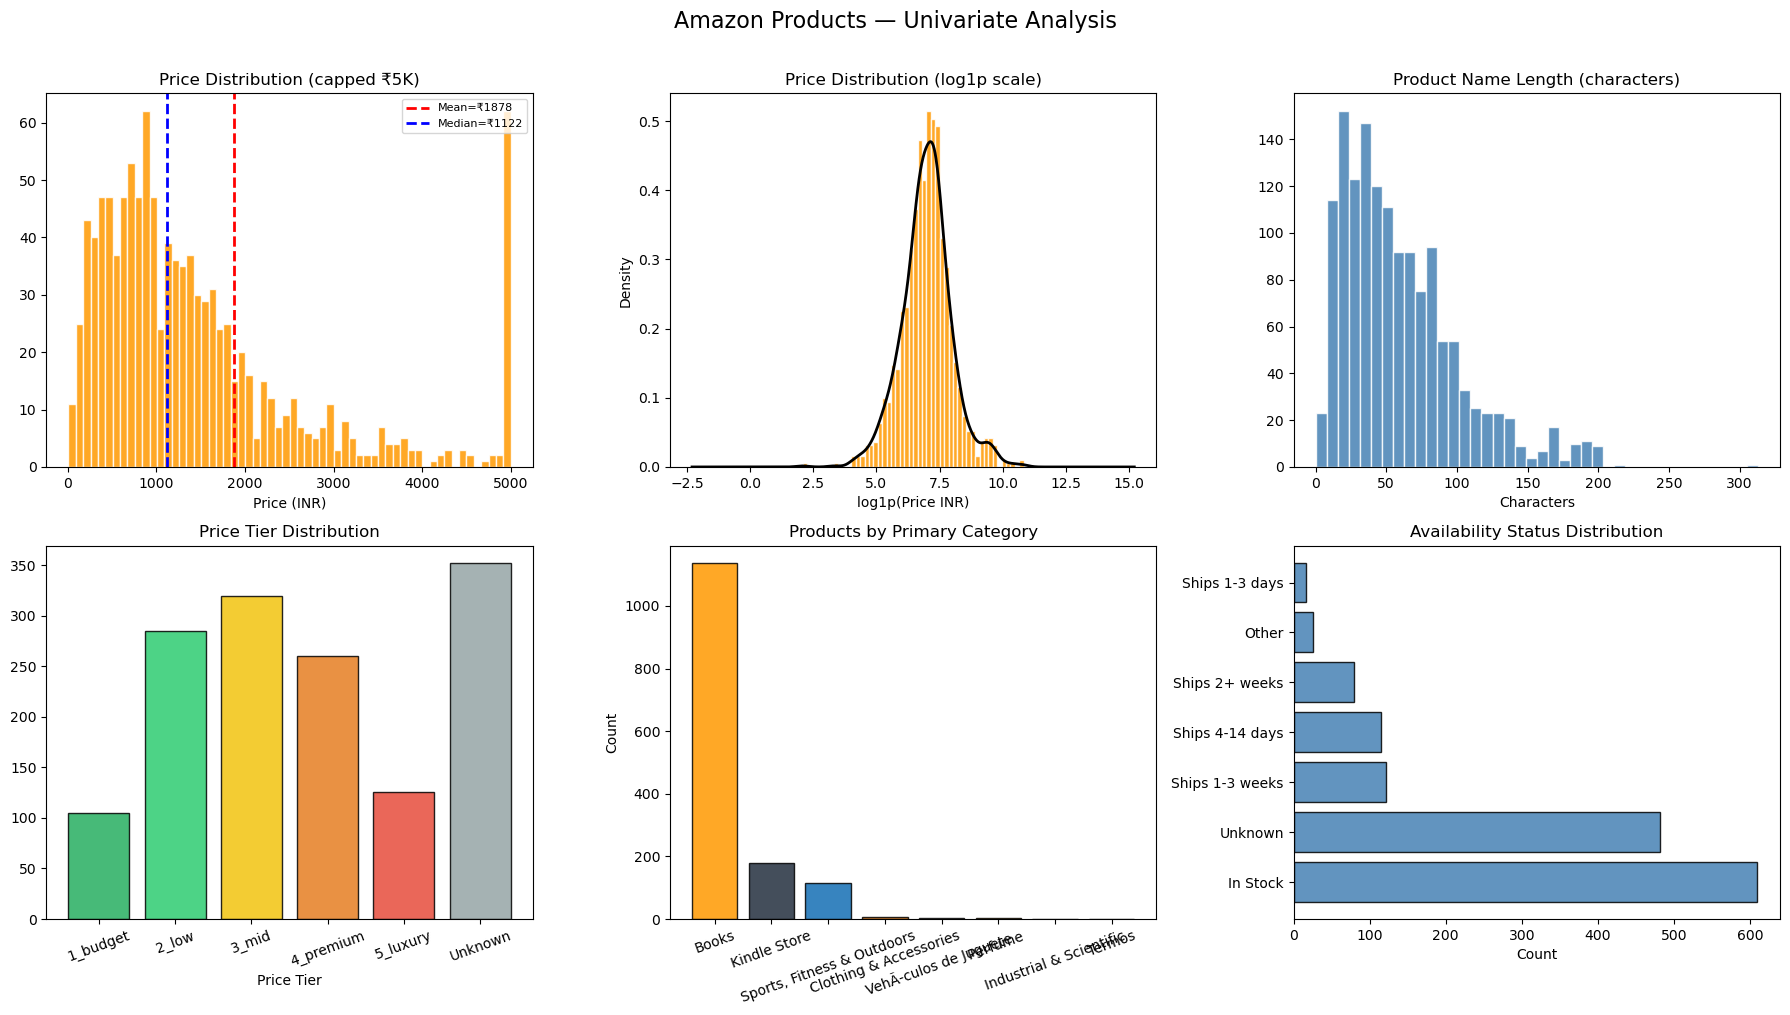

Shapiro-Wilk (log price, n=500): stat=0.9854, p=0.000066
Price is still non-normal after log transform

Price stats (INR):
count     1089.00
mean      1878.04
std       3337.00
min          7.00
25%        612.00
50%       1122.00
75%       1849.00
max      50555.00


In [100]:
# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price raw
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Mean=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Median=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Price Distribution (capped ₹5K)')
axes[0,0].set_xlabel('Price (INR)'); axes[0,0].legend(fontsize=8)

# Price log
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price INR)')

# Name length
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# Price tier
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier'); axes[1,0].tick_params(axis='x', rotation=20)

# Primary category
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count'); axes[1,1].tick_params(axis='x', rotation=20)

# Availability
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Normality test
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (log price, n=500): stat={stat:.4f}, p={p:.6f}')
print(f'Price is {"normally distributed after log transform" if p > 0.05 else "still non-normal after log transform"}')
print(f'\nPrice stats (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

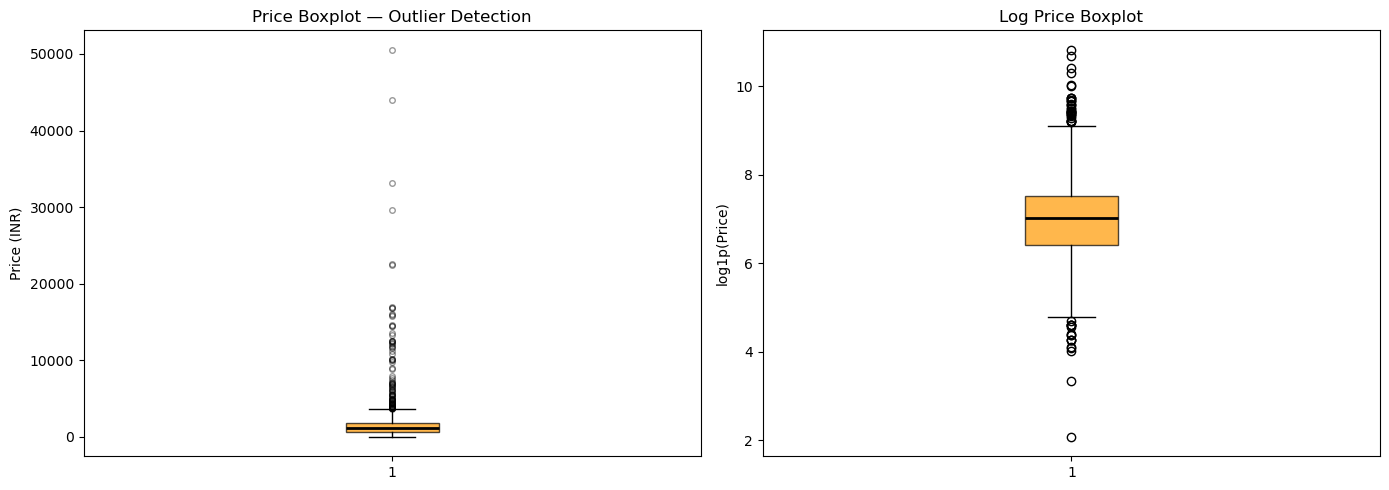

IQR method outliers: 93 (8.5%)
Price range (non-outlier): ₹-1244 – ₹3704

Top 10 most expensive products:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     29633.00                 

In [101]:
# Outlier analysis — boxplot and IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Price Boxplot — Outlier Detection')
axes[0].set_ylabel('Price (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Log Price Boxplot')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'IQR method outliers: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Price range (non-outlier): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nTop 10 most expensive products:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))

## 6.Análisis de categorías (Category Analysis) <a id='s6'></a> 

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pregunta clave: </b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se encuentra la mejor relación calidad-precio?
</div>

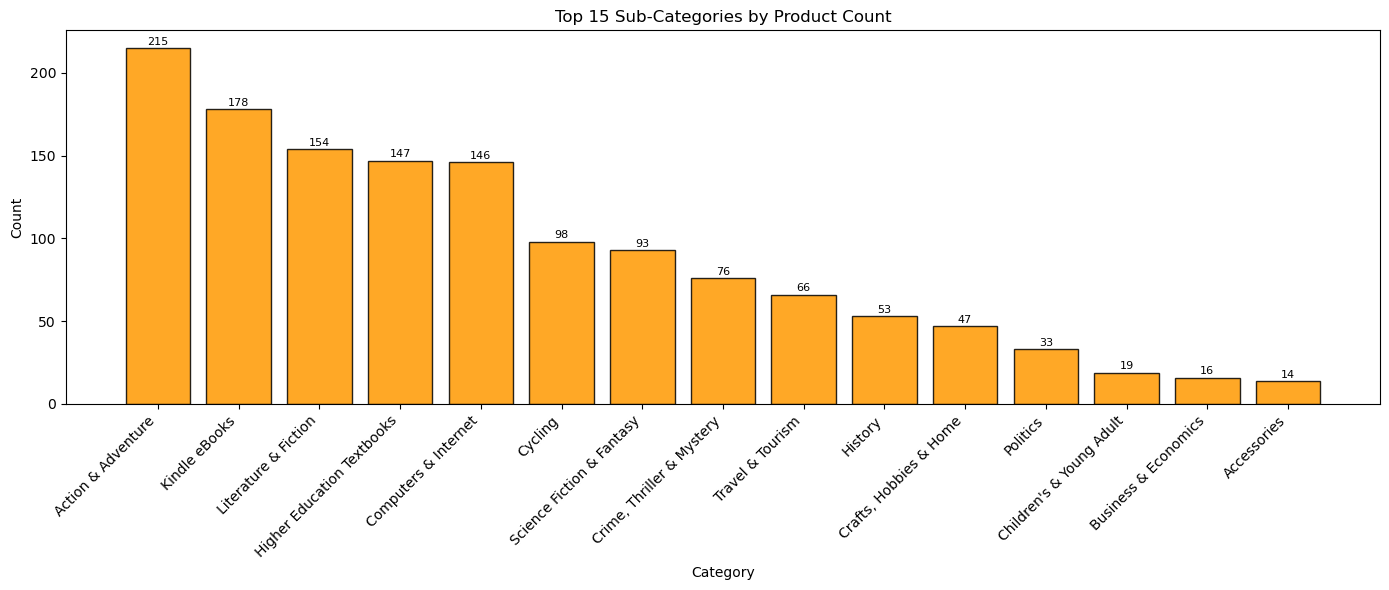

In [102]:
# ============================================================
# SECTION 5 — Category Analysis
# ============================================================
# Top 15 sub-categories by count
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

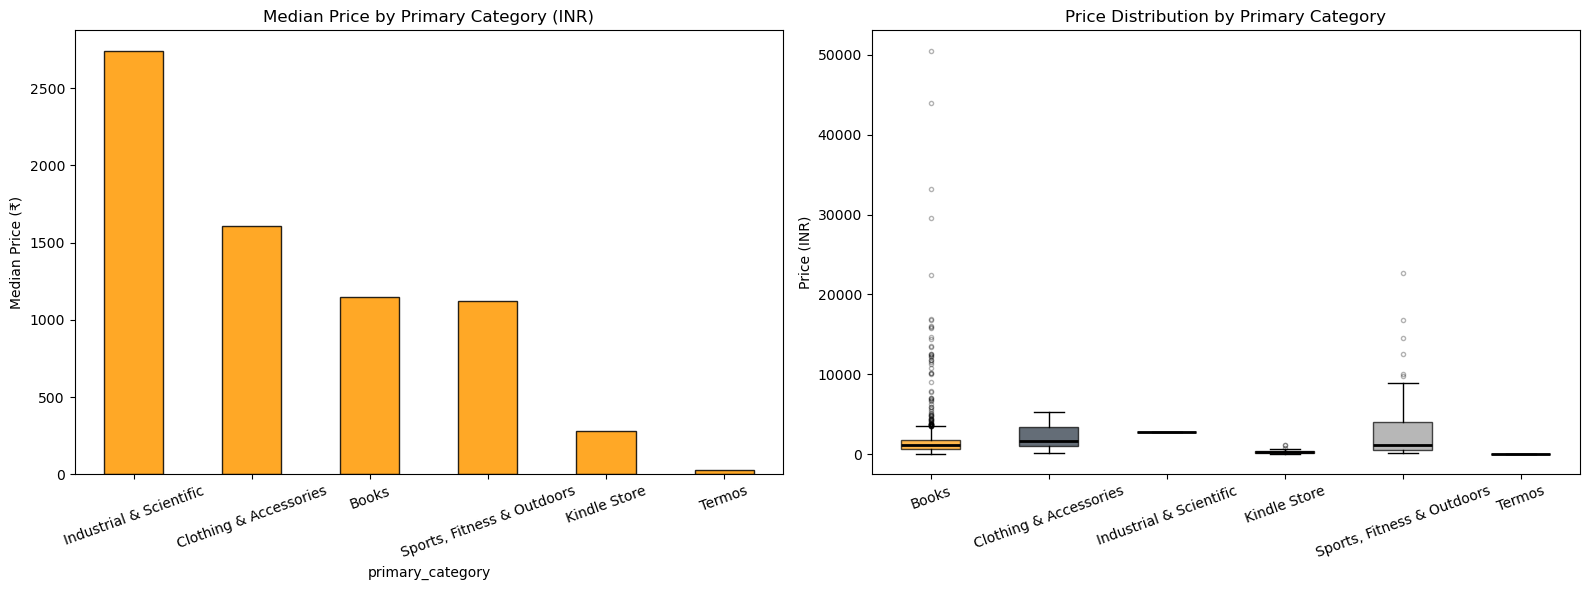

Price stats by primary category:
                              mean  median  count
primary_category                                 
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93
Termos                        27.0    27.0      1


In [103]:
# Price by primary category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)')
axes[0].tick_params(axis='x', rotation=20)

# Boxplot
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]

bp = axes[1].boxplot(
    cat_groups,
    tick_labels=cat_price.index,  # ← cambio aquí
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']

for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('Price stats by primary category:')
print(cat_price.to_string())

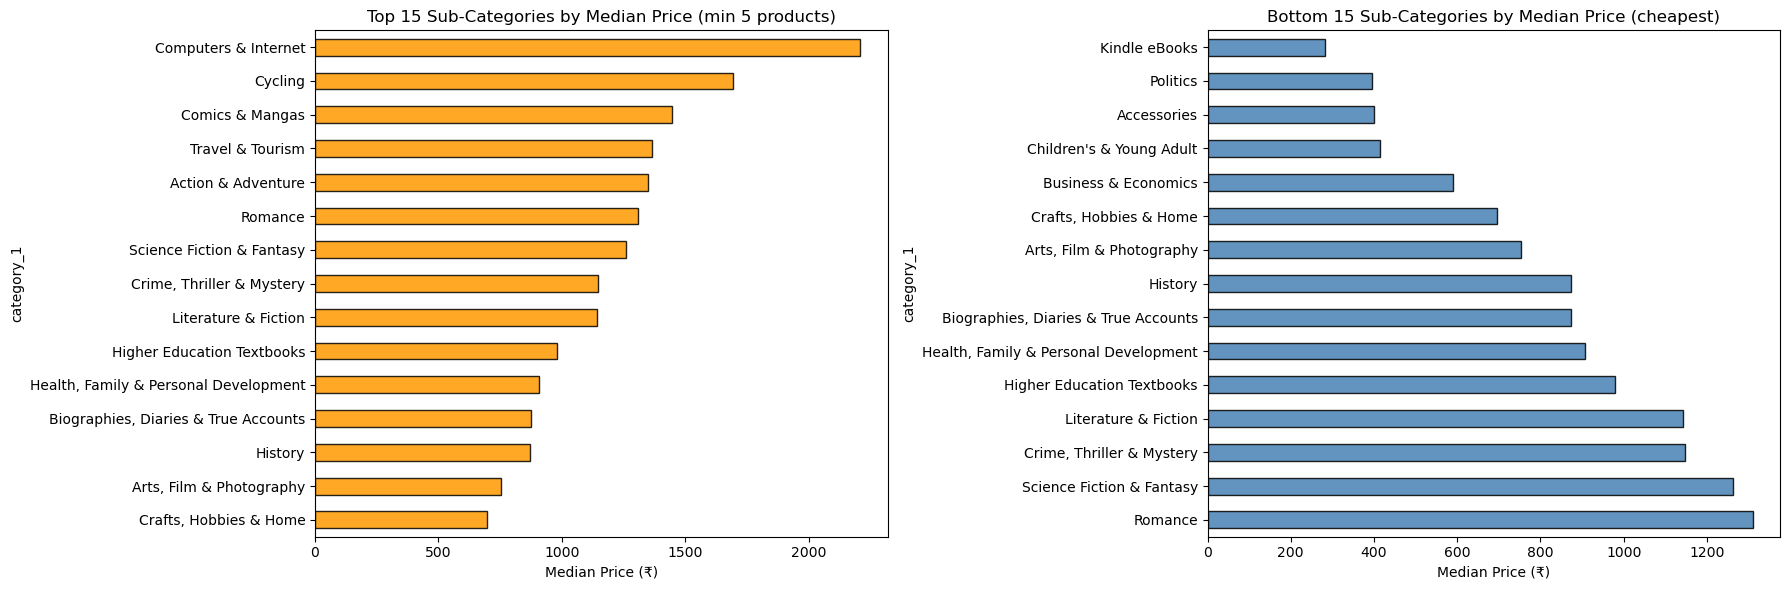

In [104]:
# Top 15 sub-categories by median price
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')

# Bottom 15 (cheapest)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')

plt.tight_layout(); plt.show()

## 7.Análisis de disponibilidad (Availability Analysis) <a id='s7'></a> 

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave: </b> ¿Influye la disponibilidad en el precio? ¿Es más probable que los productos premium se agoten?
</div>

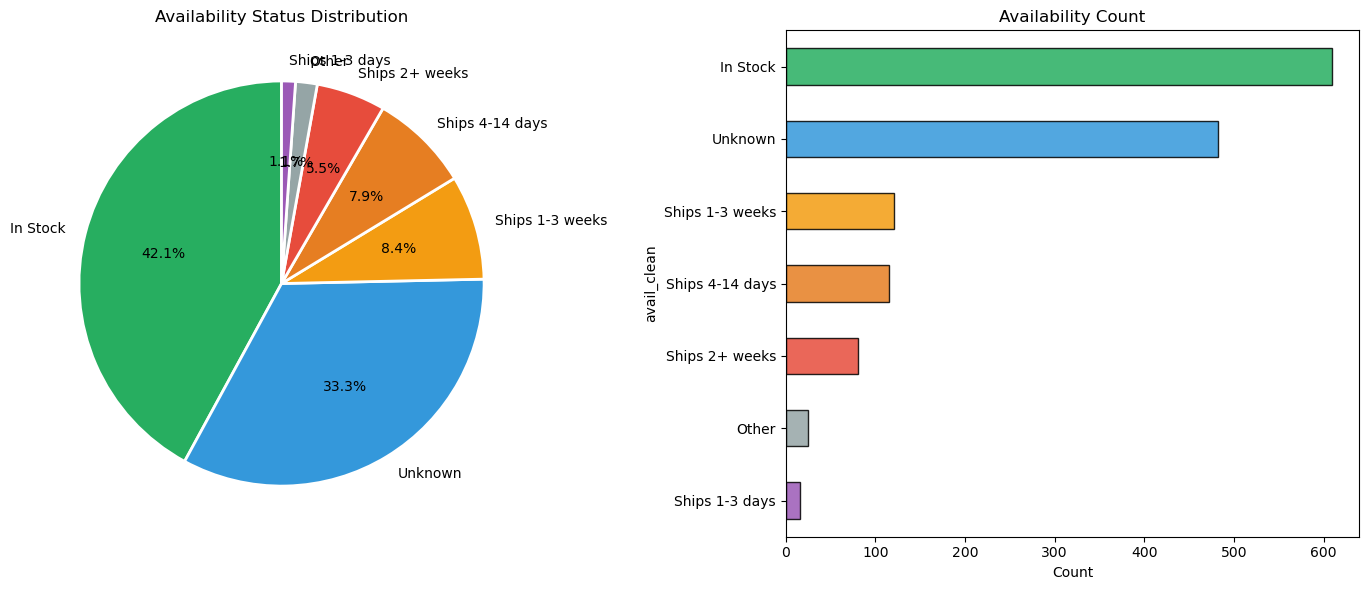

In [105]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Availability Status Distribution')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()

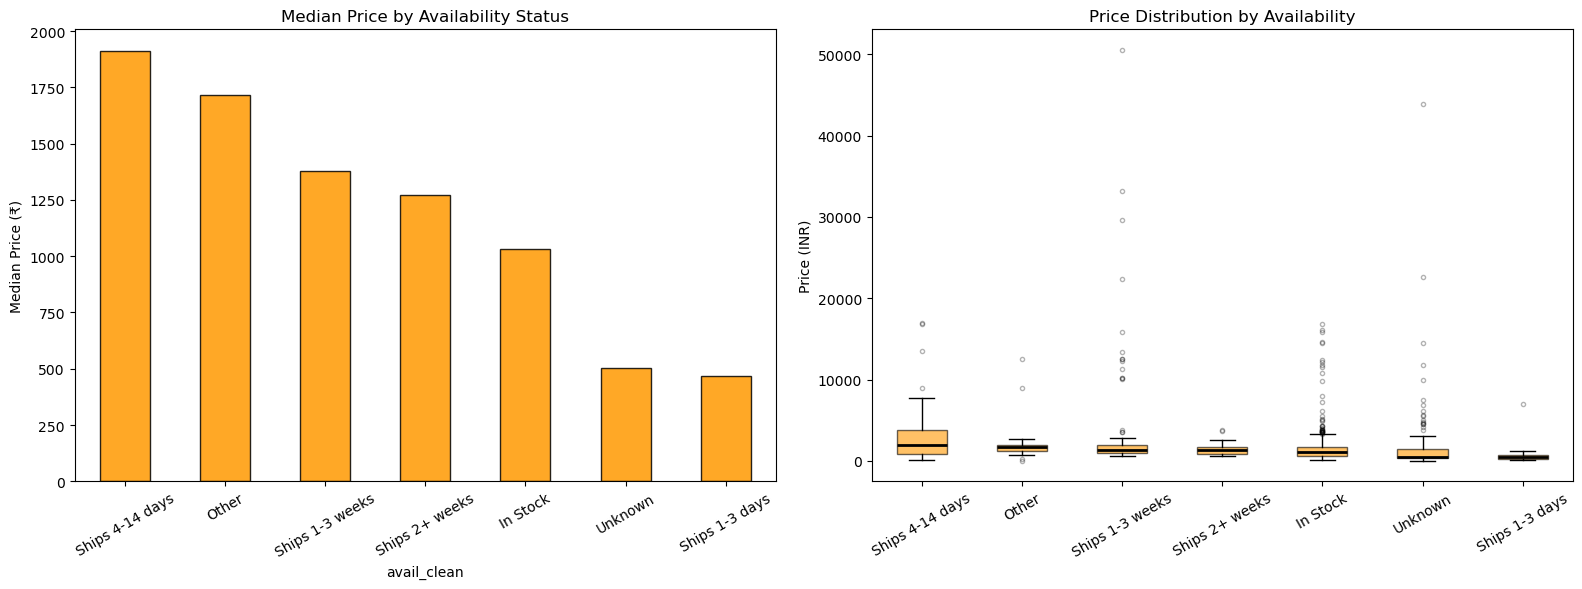

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1718.0  2343.6     21
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1031.0  1490.5    601
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [106]:
# Price by availability status

avail_price = (
    df_priced.groupby('avail_clean')['price_clean']
    .agg(['median', 'mean', 'count'])
    .round(1)
)

avail_price = (
    avail_price[avail_price['count'] >= 5]
    .sort_values('median', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
avail_price['median'].plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)')
axes[0].tick_params(axis='x', rotation=30)

# Boxplot
avail_groups = [
    df_priced[df_priced['avail_clean'] == a]['price_clean'].dropna()
    for a in avail_price.index
]

bp = axes[1].boxplot(
    avail_groups,
    tick_labels=avail_price.index,  # corregido
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

for patch in bp['boxes']:
    patch.set_facecolor('#FF9900')
    patch.set_alpha(0.6)

axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Price by availability:')
print(avail_price.to_string())

## 8.Análisis de correlación y bivariado (Correlation & Bivariate Analysis) <a id='s8'></a> 

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre predice el precio?
</div>

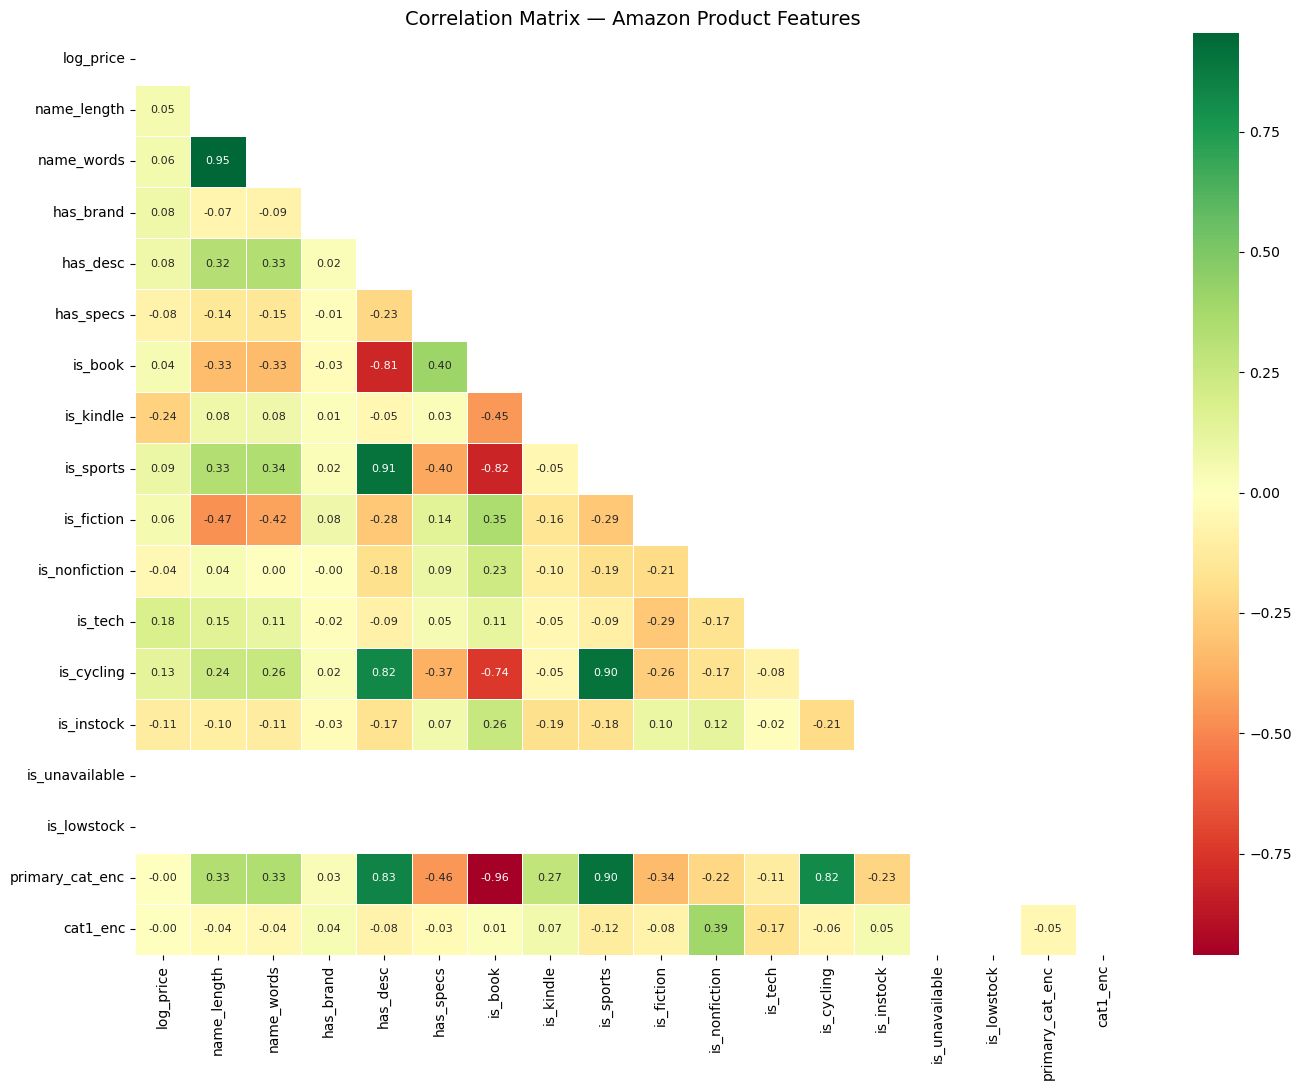

Top correlations with log_price:
is_tech            0.176684
is_cycling         0.126903
is_sports          0.092321
has_brand          0.082988
has_desc           0.081378
name_words         0.058492
is_fiction         0.055768
name_length        0.053223
is_book            0.043470
primary_cat_enc   -0.001162
cat1_enc          -0.002536
is_nonfiction     -0.041991
has_specs         -0.075614
is_instock        -0.108085
is_kindle         -0.244538
is_unavailable          NaN
is_lowstock             NaN


In [107]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

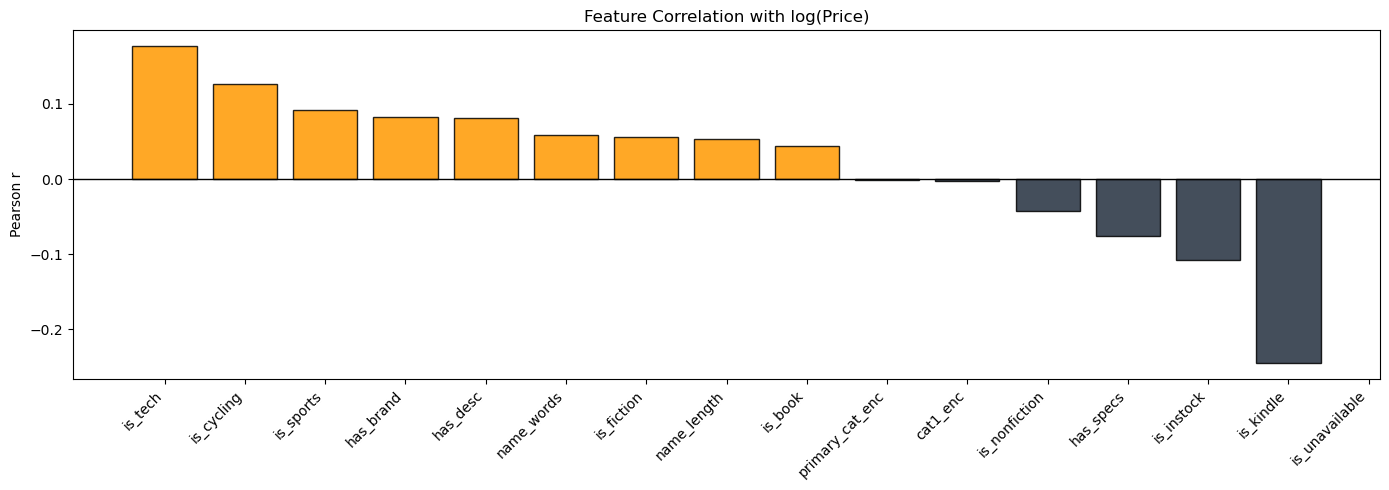

In [108]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

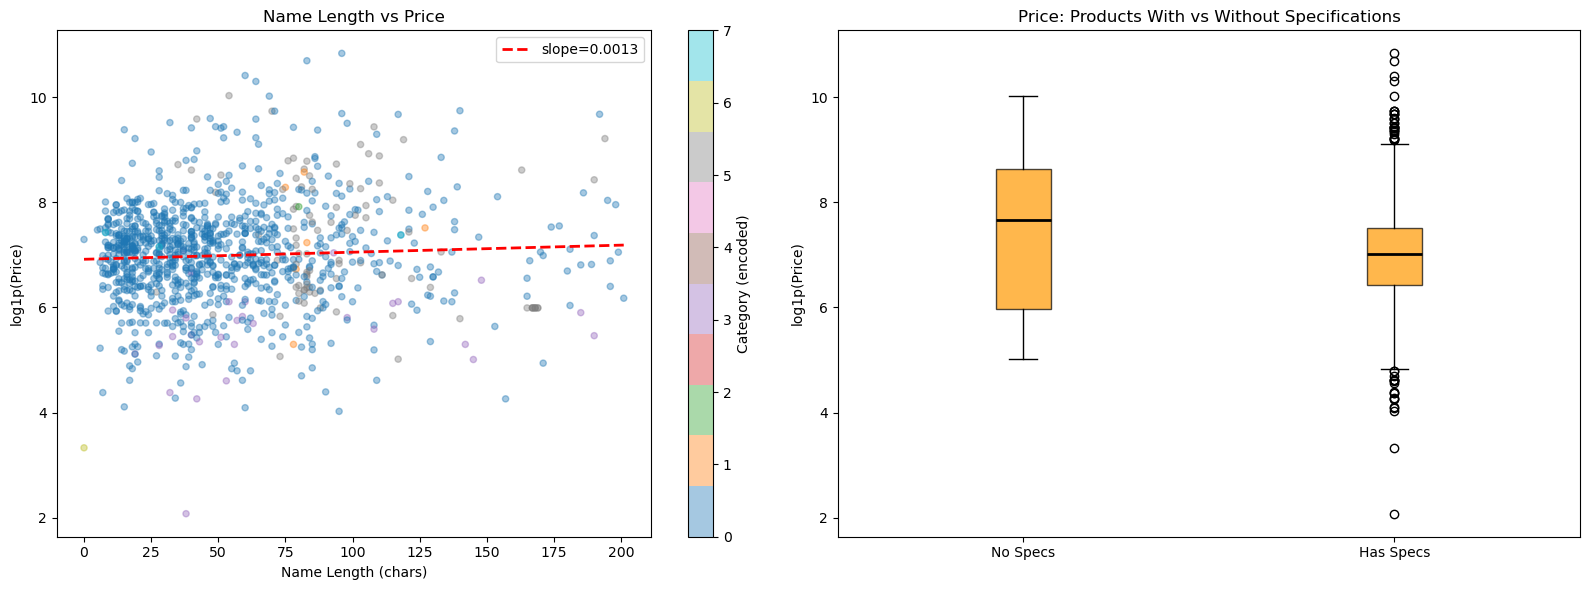

In [109]:
# Scatter: name length vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Category (encoded)')
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'slope={m:.4f}')
axes[0].set_xlabel('Name Length (chars)'); axes[0].set_ylabel('log1p(Price)')
axes[0].set_title('Name Length vs Price'); axes[0].legend()

# Price by has_specs
axes[1].boxplot(
    [np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
     np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
    tick_labels=['No Specs', 'Has Specs'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)
axes[1].set_title('Price: Products With vs Without Specifications')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

## 9.Prueba de hipótesis estadísticas (Statistical Hypothesis Testing) <a id='s9'></a> 

<div style="background:#fff8e1; padding:12px; border-left:4px solid #e74c3c; border-radius:5px; color: #0066cc;">
Utilizamos <b>pruebas no paramétricas</b> (Kruskal-Wallis, U de Mann-Whitney) debido a que el precio presenta una distribución asimétrica y no normal. α = 0,05.
</div>

| # | Hipótesis | Descripción |
|---|---|---|
| 1 | H1: El precio difiere significativamente entre las categorías principales | Se evalúa si existen diferencias estadísticamente significativas en los precios de los productos según su categoría principal utilizando la prueba Kruskal-Wallis. |
| 2 | H2: Los libros tienen precios significativamente menores que los productos deportivos | Se compara la distribución de precios entre las categorías de libros y deportes mediante la prueba Mann-Whitney U. |
| 3 | H3: Los productos en stock tienen precios diferentes a los productos no disponibles | Se analiza si la disponibilidad del producto influye en el precio utilizando la prueba Mann-Whitney U. |
| 4 | H4: La longitud del nombre del producto está correlacionada positivamente con el precio | Se determina la relación entre la cantidad de caracteres del nombre del producto y su precio mediante la correlación de Spearman. |
| 5 | H5: Los productos con especificaciones tienen precios más altos | Se compara el precio de productos con y sin especificaciones técnicas utilizando la prueba Mann-Whitney U. |



In [110]:
# ============================================================
# IMPORTS NECESARIOS
# ============================================================
from scipy.stats import kruskal, mannwhitneyu, spearmanr

# ============================================================
# SECTION 8 — Hypothesis Testing
# ============================================================
alpha = 0.05

def mw_test(name, a, b, la, lb):
    a = a.dropna()
    b = b.dropna()

    if len(a) == 0 or len(b) == 0:
        print(f'{name}')
        print('  ERROR: Uno de los grupos no tiene datos suficientes.')
        print()
        return None

    u, p = mannwhitneyu(a, b, alternative='two-sided')

    print(f'{name}')
    print(f'  {la}: n={len(a)}, median=₹{a.median():.0f}')
    print(f'  {lb}: n={len(b)}, median=₹{b.median():.0f}')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULT: {"✅ REJECT H0 — Significant difference." if p < alpha else "❌ FAIL TO REJECT H0."}')
    print()

    return p

# ============================================================
# H1: Price across primary categories — Kruskal-Wallis
# ============================================================

cat_groups_kw = []
cat_labels_kw = []

for c in df_priced['primary_category'].dropna().unique():
    group = df_priced.loc[
        df_priced['primary_category'] == c,
        'price_clean'
    ].dropna()

    if len(group) >= 5:
        cat_groups_kw.append(group)
        cat_labels_kw.append(c)

if len(cat_groups_kw) >= 2:

    h1, p1 = kruskal(*cat_groups_kw)

    print('H1: Price across Primary Categories — Kruskal-Wallis')

    for label, g in zip(cat_labels_kw, cat_groups_kw):
        print(f'  {label:35s}: n={len(g)}, median=₹{g.median():.0f}')

    print(f'  H={h1:.4f}, p={p1:.6f}')
    print(f'  RESULT: {"✅ REJECT H0 — Price differs across categories." if p1 < alpha else "❌ FAIL TO REJECT H0."}')
    print()

else:
    print('H1: No hay suficientes categorías con al menos 5 registros.')
    print()

# ============================================================
# H2: Books vs Sports
# ============================================================

p2 = mw_test(
    'H2: Books vs Sports Products Price',
    df_priced.loc[df_priced['is_book'] == 1, 'price_clean'],
    df_priced.loc[df_priced['is_sports'] == 1, 'price_clean'],
    'Books',
    'Sports'
)

# ============================================================
# H3: In Stock vs Unavailable
# ============================================================

p3 = mw_test(
    'H3: In-Stock vs Unavailable Price',
    df_priced.loc[df_priced['is_instock'] == 1, 'price_clean'],
    df_priced.loc[df_priced['is_unavailable'] == 1, 'price_clean'],
    'In Stock',
    'Unavailable'
)

# ============================================================
# H4: Name length vs price — Spearman
# ============================================================

corr_df = df_priced[['name_length', 'price_clean']].dropna()

rho4, p4 = spearmanr(
    corr_df['name_length'],
    corr_df['price_clean']
)

print('H4: Name Length vs Price — Spearman Correlation')
print(f'  rho={rho4:.4f}, p={p4:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Significant correlation." if p4 < alpha else "❌ FAIL TO REJECT H0."}')
print()

# ============================================================
# H5: Has specs vs no specs
# ============================================================

p5 = mw_test(
    'H5: Products With vs Without Specifications',
    df_priced.loc[df_priced['has_specs'] == 1, 'price_clean'],
    df_priced.loc[df_priced['has_specs'] == 0, 'price_clean'],
    'Has Specs',
    'No Specs'
)

H1: Price across Primary Categories — Kruskal-Wallis
  Books                              : n=955, median=₹1145
  Sports, Fitness & Outdoors         : n=93, median=₹1125
  Kindle Store                       : n=30, median=₹281
  Clothing & Accessories             : n=6, median=₹1606
  H=55.8663, p=0.000000
  RESULT: ✅ REJECT H0 — Price differs across categories.

H2: Books vs Sports Products Price
  Books: n=955, median=₹1145
  Sports: n=93, median=₹1125
  Mann-Whitney U=40247, p=0.135443
  RESULT: ❌ FAIL TO REJECT H0.

H3: In-Stock vs Unavailable Price
  ERROR: Uno de los grupos no tiene datos suficientes.

H4: Name Length vs Price — Spearman Correlation
  rho=0.0355, p=0.242098
  RESULT: ❌ FAIL TO REJECT H0.

H5: Products With vs Without Specifications
  Has Specs: n=1065, median=₹1116
  No Specs: n=24, median=₹2207
  Mann-Whitney U=10048, p=0.073079
  RESULT: ❌ FAIL TO REJECT H0.



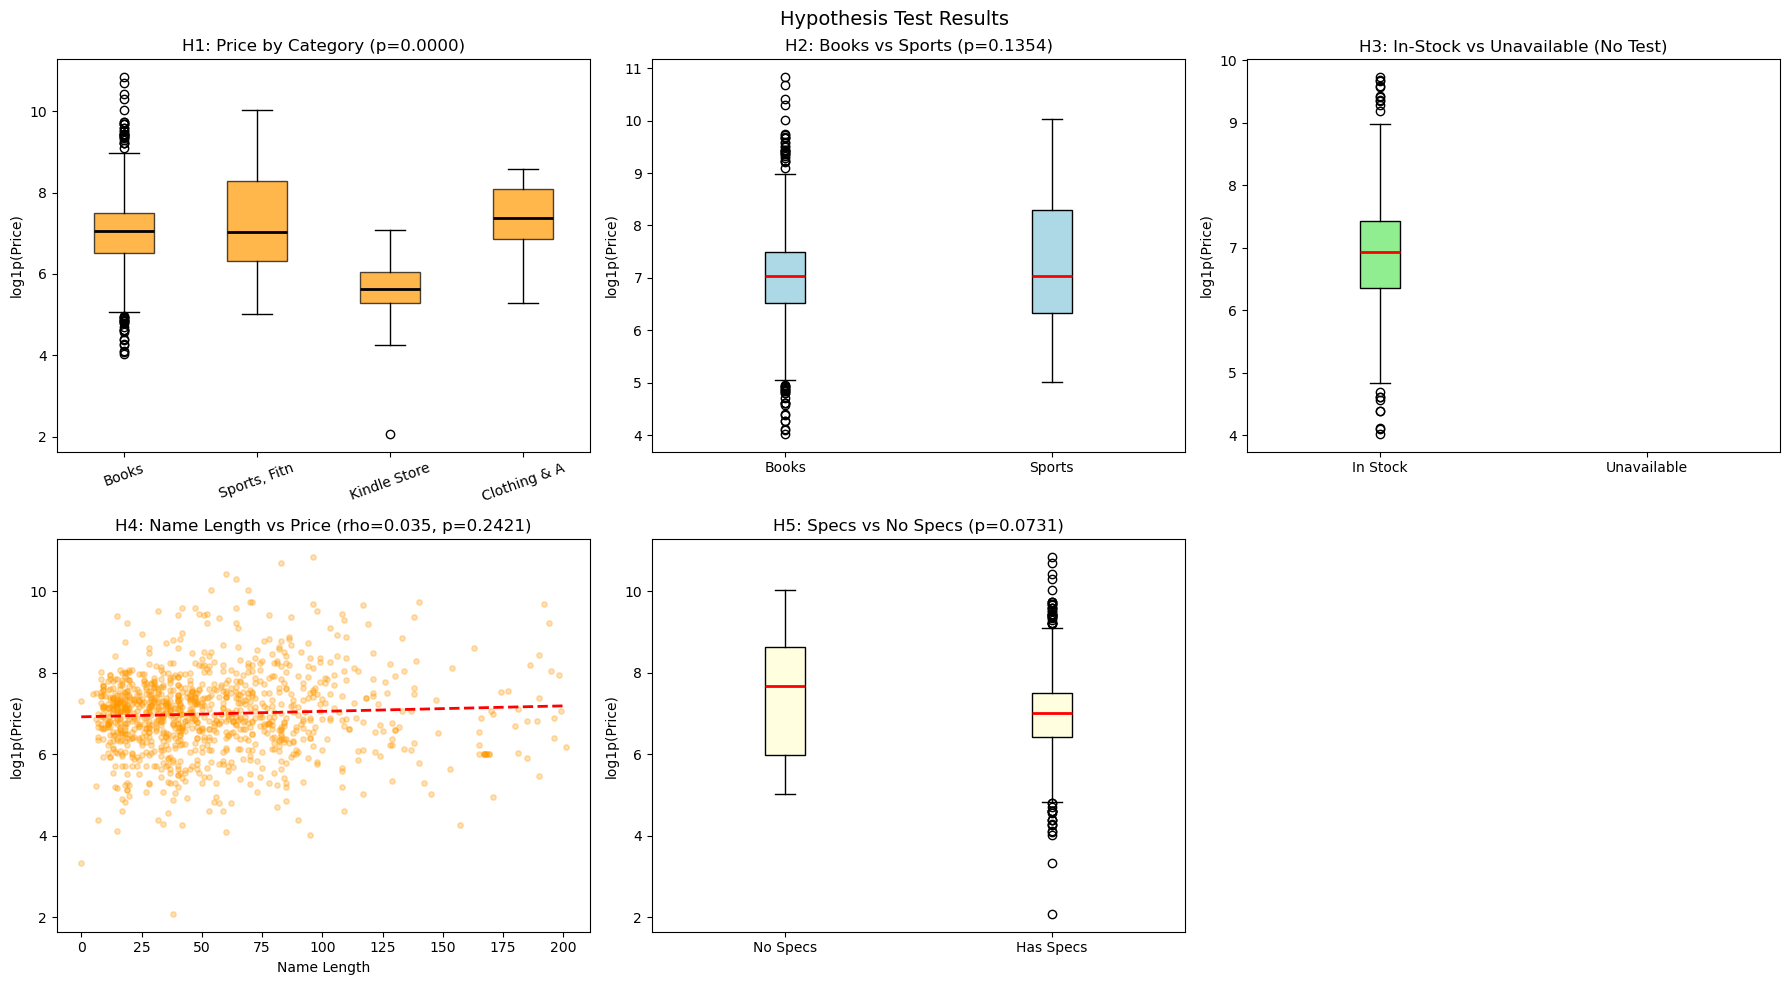

In [111]:
# Visualise hypothesis results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# =========================
# H1
# =========================
axes[0,0].boxplot(
    [np.log1p(g) for g in cat_groups_kw],
    tick_labels=[l[:12] for l in cat_labels_kw],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)

title_h1 = f'H1: Price by Category (p={p1:.4f})' if p1 is not None else 'H1: Price by Category'
axes[0,0].set_title(title_h1)
axes[0,0].set_ylabel('log1p(Price)')
axes[0,0].tick_params(axis='x', rotation=20)

# =========================
# H2
# =========================
axes[0,1].boxplot(
    [
        np.log1p(df_priced[df_priced['is_book']==1]['price_clean'].dropna()),
        np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'].dropna())
    ],
    tick_labels=['Books', 'Sports'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', lw=2)
)

title_h2 = f'H2: Books vs Sports (p={p2:.4f})' if p2 is not None else 'H2: Books vs Sports'
axes[0,1].set_title(title_h2)
axes[0,1].set_ylabel('log1p(Price)')

# =========================
# H3
# =========================
axes[0,2].boxplot(
    [
        np.log1p(df_priced[df_priced['is_instock']==1]['price_clean'].dropna()),
        np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'].dropna())
    ],
    tick_labels=['In Stock', 'Unavailable'],
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen'),
    medianprops=dict(color='red', lw=2)
)

title_h3 = f'H3: In-Stock vs Unavailable (p={p3:.4f})' if p3 is not None else 'H3: In-Stock vs Unavailable (No Test)'
axes[0,2].set_title(title_h3)
axes[0,2].set_ylabel('log1p(Price)')

# =========================
# H4
# =========================
axes[1,0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    alpha=0.3,
    color='#FF9900',
    s=15
)

valid = df_priced[['name_length', 'log_price']].dropna()

if len(valid) > 1:
    m, b = np.polyfit(valid['name_length'], valid['log_price'], 1)

    x = np.linspace(
        valid['name_length'].min(),
        valid['name_length'].max(),
        100
    )

    axes[1,0].plot(x, m*x+b, 'r--', lw=2)

title_h4 = f'H4: Name Length vs Price (rho={rho4:.3f}, p={p4:.4f})'
axes[1,0].set_title(title_h4)
axes[1,0].set_xlabel('Name Length')
axes[1,0].set_ylabel('log1p(Price)')

# =========================
# H5
# =========================
axes[1,1].boxplot(
    [
        np.log1p(df_priced[df_priced['has_specs']==0]['price_clean'].dropna()),
        np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'].dropna())
    ],
    tick_labels=['No Specs', 'Has Specs'],
    patch_artist=True,
    boxprops=dict(facecolor='lightyellow'),
    medianprops=dict(color='red', lw=2)
)

title_h5 = f'H5: Specs vs No Specs (p={p5:.4f})' if p5 is not None else 'H5: Specs vs No Specs'
axes[1,1].set_title(title_h5)
axes[1,1].set_ylabel('log1p(Price)')

# =========================
# Empty panel
# =========================
axes[1,2].set_visible(False)

plt.suptitle('Hypothesis Test Results', fontsize=14)
plt.tight_layout()
plt.show()

## 10.Formulación de problemas de aprendizaje automático (ML Problem Framing) <a id='s10'></a> 

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Tarea:</b> Predice el precio del producto (en escala logarítmica) a partir de la categoría, la longitud del nombre, la disponibilidad y los indicadores de características.<br>
<b>¿Por qué registrar el precio?</b> El precio bruto presenta una marcada asimetría positiva. La transformación logarítmica lo normaliza y evita que los valores atípicos costosos dominen la función de pérdida.
</div>

✅ ML dataset shape : (1089, 20)
✅ Features         : 18

Train: 871 | Test: 218


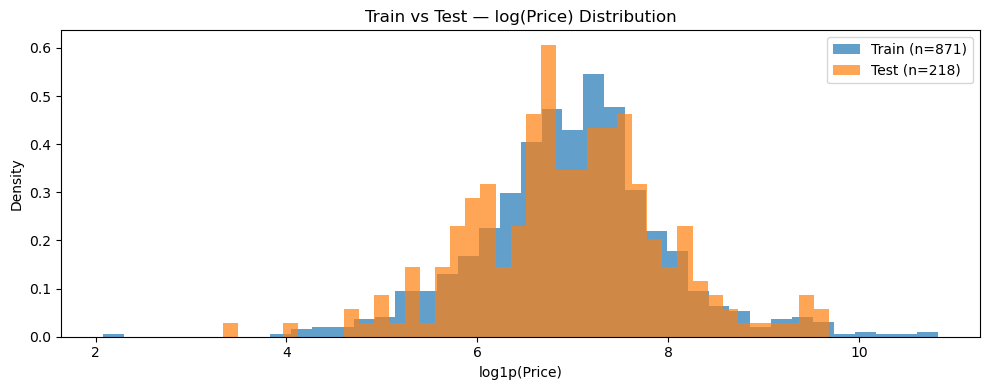

✅ Distributions look similar — good split!


In [112]:
# ============================================================
# SECTION 9 — ML Problem Framing
# ============================================================

# Imports necesarios
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [
    'name_length',
    'name_words',
    'has_brand',
    'has_desc',
    'has_specs',
    'is_book',
    'is_kindle',
    'is_sports',
    'is_fiction',
    'is_nonfiction',
    'is_tech',
    'is_cycling',
    'is_instock',
    'is_unavailable',
    'is_lowstock',
    'primary_cat_enc',
    'cat1_enc',
    'avail_enc'
]

TARGET = 'log_price'

# Crear dataset para ML
df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()

print(f'✅ ML dataset shape : {df_ml.shape}')
print(f'✅ Features         : {len(FEATURE_COLS)}')

# Variables predictoras y objetivo
X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Escalado
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

# ============================================================
# Visualización de la división
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    y_train,
    bins=40,
    alpha=0.7,
    label=f'Train (n={len(y_train)})',
    density=True
)

ax.hist(
    y_test,
    bins=40,
    alpha=0.7,
    label=f'Test (n={len(y_test)})',
    density=True
)

ax.set_title('Train vs Test — log(Price) Distribution')
ax.set_xlabel('log1p(Price)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

print('✅ Distributions look similar — good split!')

## 11.Formulación de problemas de aprendizaje automático (ML Problem Framing) <a id='s11'></a> 

| Modelo | Fortalezas | Debilidades | Mejor para |
|---------|------------|-------------|-------------|
| **Regresión Lineal** | Rápida, fácil de interpretar | Asume una relación lineal | Línea base (baseline) |
| **Regresión Ridge** | Maneja la multicolinealidad | Sigue siendo lineal | Variables correlacionadas |
| **Regresión Lasso** | Selección automática de variables | Puede eliminar variables útiles | Conjuntos de datos dispersos |
| **Random Forest** | No lineal, robusto | Menos interpretable | Patrones complejos |
| **XGBoost / GBM** | Mayor precisión | Requiere ajuste de hiperparámetros | Datos tabulares |


## Métricas de Evaluación

- **MAE** — Error Absoluto Medio en escala logarítmica (menor = mejor)
- **RMSE** — Raíz del Error Cuadrático Medio (penaliza más los errores grandes)
- **R²** — Coeficiente de determinación o varianza explicada (mayor = mejor, máximo = 1.0)
- **MAE (₹)** — Error Absoluto Medio convertido nuevamente a rupias (INR) para una interpretación de negocio

In [113]:
# ============================================================
# SECTION 10 — Evaluation Helpers
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Evaluation helpers ready.')

✅ Evaluation helpers ready.


## 12.Modelos de regresión ( Regression Models) <a id='s12'></a> 

In [114]:
# ============================================================
# SECTION 11 — Train All Models
# ============================================================
print('='*60)
print('TRAINING ALL MODELS')
print('='*60)

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = eval_model('Linear Regression', y_test, lr.predict(X_test_s))

# 2. Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = eval_model('Ridge Regression', y_test, ridge.predict(X_test_s))

# 3. Lasso Regression
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = eval_model('Lasso Regression', y_test, lasso.predict(X_test_s))

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = eval_model('Random Forest', y_test, rf.predict(X_test))

# 5. XGBoost / GBM
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05,
                                   max_depth=5, subsample=0.8,
                                   colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    xgb_pred = eval_model('XGBoost', y_test, xgb_model.predict(X_test))
else:
    gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                     max_depth=5, subsample=0.8, random_state=42)
    gbm.fit(X_train, y_train)
    xgb_pred = eval_model('Gradient Boosting', y_test, gbm.predict(X_test))

TRAINING ALL MODELS
  📊 Linear Regression:
     MAE (log)  = 0.7521  |  MAE (₹) = ₹1,207
     RMSE (log) = 1.0018  |  R²      = 0.0126
  📊 Ridge Regression:
     MAE (log)  = 0.7485  |  MAE (₹) = ₹1,198
     RMSE (log) = 0.9966  |  R²      = 0.0229
  📊 Lasso Regression:
     MAE (log)  = 0.7399  |  MAE (₹) = ₹1,169
     RMSE (log) = 0.9835  |  R²      = 0.0483
  📊 Random Forest:
     MAE (log)  = 0.6828  |  MAE (₹) = ₹1,091
     RMSE (log) = 0.9104  |  R²      = 0.1845
  📊 Gradient Boosting:
     MAE (log)  = 0.7118  |  MAE (₹) = ₹1,136
     RMSE (log) = 0.9544  |  R²      = 0.1039


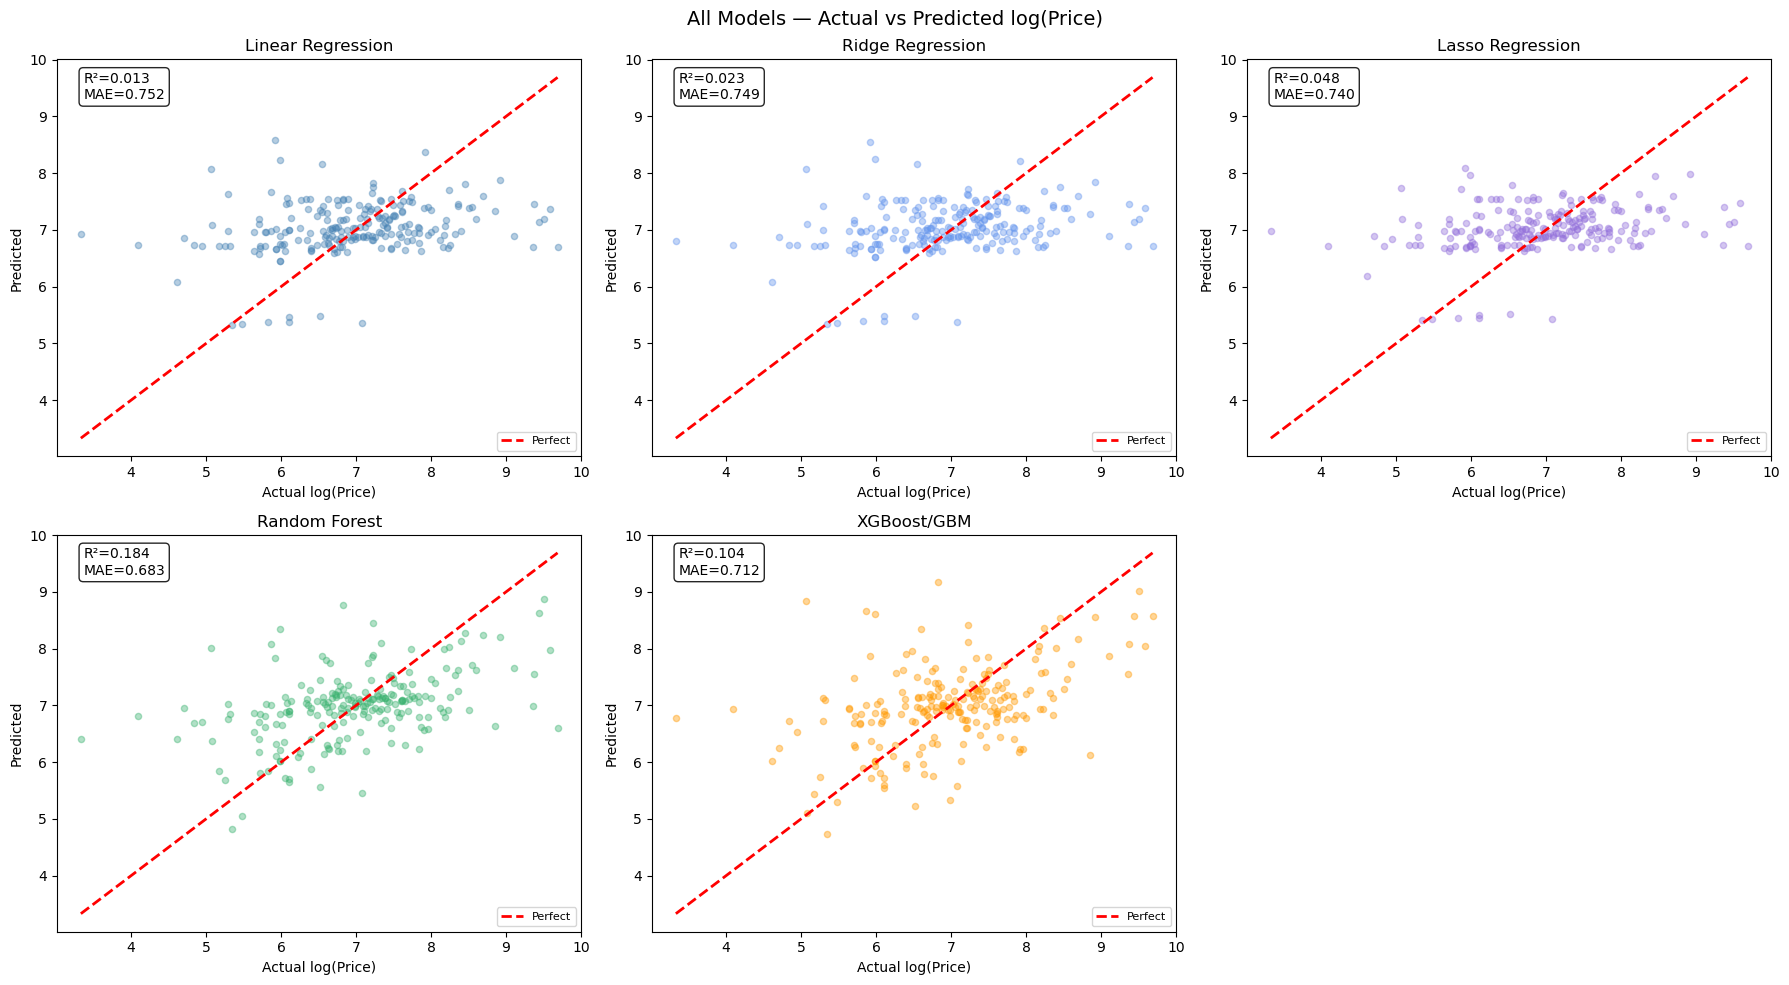

In [115]:
# Actual vs Predicted — all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
preds_all = [('Linear Regression', lr_pred, 'steelblue'),
             ('Ridge Regression',  ridge_pred, 'cornflowerblue'),
             ('Lasso Regression',  lasso_pred, 'mediumpurple'),
             ('Random Forest',      rf_pred,    'mediumseagreen'),
             ('XGBoost/GBM',        xgb_pred,   '#FF9900')]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect')
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    ax.set_title(f'{name}')
    ax.set_xlabel('Actual log(Price)'); ax.set_ylabel('Predicted')
    ax.annotate(f'R²={r2v:.3f}\nMAE={maev:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.legend(fontsize=8)

# FIX: Use flatten() to access the last individual subplot index
axes.flatten()[-1].set_visible(False)

plt.suptitle('All Models — Actual vs Predicted log(Price)', fontsize=14)
plt.tight_layout(); plt.show()

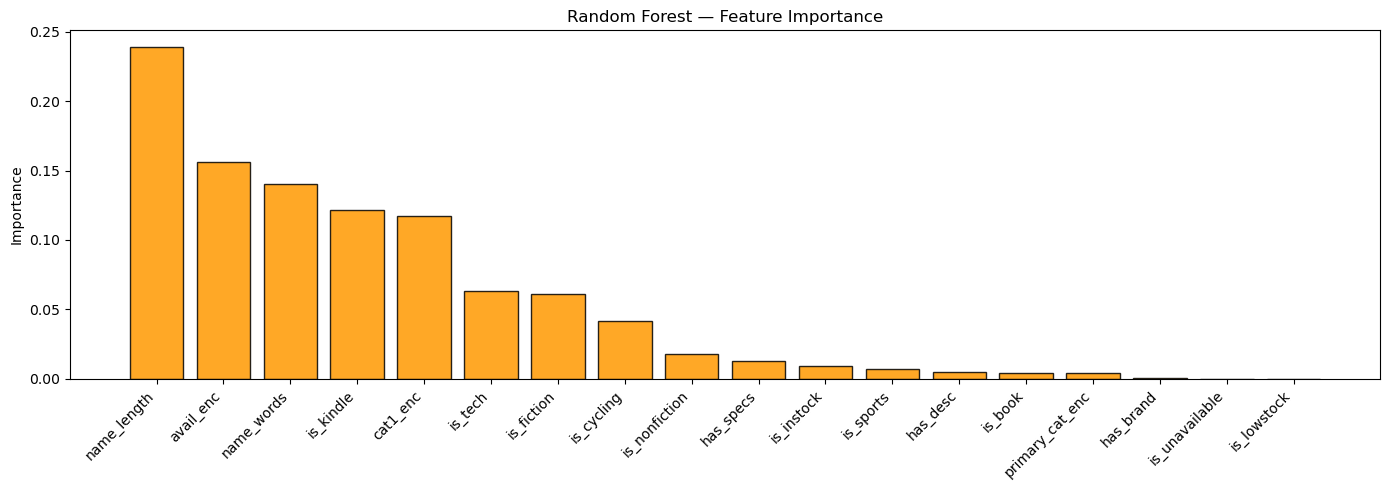

Top 10 most important features:
      Feature  Importance
  name_length    0.239054
    avail_enc    0.155824
   name_words    0.140425
    is_kindle    0.121279
     cat1_enc    0.117175
      is_tech    0.063258
   is_fiction    0.060983
   is_cycling    0.041537
is_nonfiction    0.017925
    has_specs    0.012541


In [116]:
# Feature importance — Random Forest
feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(feat_imp['Feature'], feat_imp['Importance'],
        color='#FF9900', edgecolor='black', alpha=0.85)
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Top 10 most important features:')
print(feat_imp.head(10).to_string(index=False))

## 13.Ajuste de hiperparámetros (Hyperparameter Tuning) <a id='s13'></a> 

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Ejemplo cotidiano:</b> Un chef ajusta el sazón hasta que el plato esté perfecto. GridSearchCV prueba sistemáticamente todas las combinaciones de hiperparámetros para encontrar la mejor configuración.

In [117]:
# ============================================================
# SECTION 12 — GridSearchCV on Random Forest
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ============================================================
# Evaluation Function
# ============================================================

def eval_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mae_rupees = int(np.expm1(mae))

    print(f'\n📊 {name}:')
    print()
    print(f'MAE (log) = {mae:.4f}  |  MAE (₹) = ₹{mae_rupees}')
    print(f'RMSE (log) = {rmse:.4f} |  R²      = {r2:.4f}')

    return {
        'Model': name,
        'MAE_log': mae,
        'MAE_rupees': mae_rupees,
        'RMSE_log': rmse,
        'R2': r2
    }

# ============================================================
# Grid Search
# ============================================================

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5]
}

print('🔍 Running GridSearchCV (this may take 1-2 minutes)...')

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f'✅ Best parameters : {grid_search.best_params_}')
print(f'✅ Best CV MAE     : {-grid_search.best_score_:.4f}')

# ============================================================
# Evaluate Tuned Model
# ============================================================

best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test)

tuned_result = eval_model(
    'Random Forest (Tuned)',
    y_test,
    best_pred
)

# Guardar resultado si existe la lista results
try:
    results.append(tuned_result)
except:
    pass

🔍 Running GridSearchCV (this may take 1-2 minutes)...
✅ Best parameters : {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 200}
✅ Best CV MAE     : 0.6490

📊 Random Forest (Tuned):

MAE (log) = 0.6836  |  MAE (₹) = ₹0
RMSE (log) = 0.9103 |  R²      = 0.1847


Random Forest (Tuned) — 5-Fold Cross-Validation:
  Fold 1: MAE = 0.6481
  Fold 2: MAE = 0.6479
  Fold 3: MAE = 0.6915
  Fold 4: MAE = 0.6167
  Fold 5: MAE = 0.6192
  Mean MAE : 0.6447 ± 0.0270


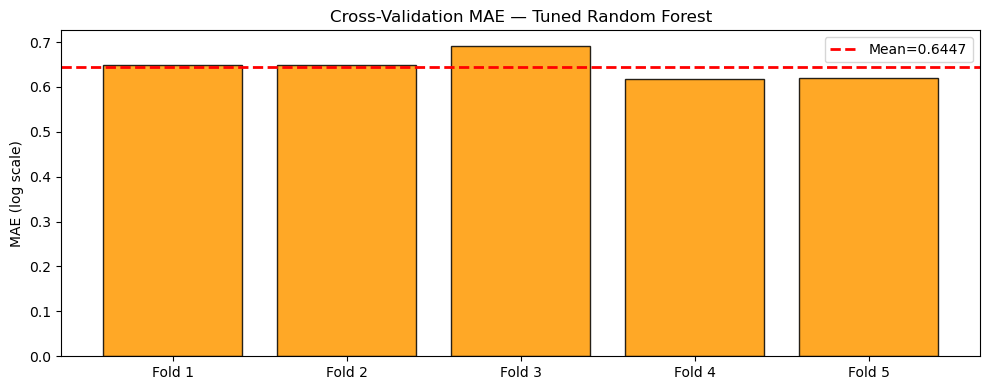

In [118]:
# Cross-validation scores — tuned model
cv_scores = cross_val_score(best_rf, X, y, cv=5,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
cv_mae = -cv_scores

print('Random Forest (Tuned) — 5-Fold Cross-Validation:')
for i, score in enumerate(cv_mae):
    print(f'  Fold {i+1}: MAE = {score:.4f}')
print(f'  Mean MAE : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 6), cv_mae, color='#FF9900', edgecolor='black', alpha=0.85)
ax.axhline(cv_mae.mean(), color='red', linestyle='--', lw=2,
           label=f'Mean={cv_mae.mean():.4f}')
ax.set_xticks(range(1, 6)); ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_title('Cross-Validation MAE — Tuned Random Forest')
ax.set_ylabel('MAE (log scale)'); ax.legend()
plt.tight_layout(); plt.show()

## 14.Comparación y selección de modelos ( Model Comparison & Selection ) <a id='s14'></a> 

<div style="
    background-color:#fff8e6;
    border-left:5px solid #ff9900;
    padding:14px 18px;
    border-radius:6px;
    color:#1a4fa3;
    font-family:Arial, sans-serif;
    margin:10px 0;
">
    <b>Borde dorado = mejor modelo para cada métrica.</b>
    Seleccionamos el modelo con el mejor equilibrio entre <b>R²</b>, <b>MAE</b> e <b>interpretabilidad</b>.
</div>

In [119]:
# ============================================================
# SECTION 13 — Model Comparison
# ============================================================
formatted_rows = []
for model_name, metrics in dict(results).items():
    # Since metrics is a sub-dictionary, we can safely pull out values by their exact keys
    if isinstance(metrics, dict):
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_INR': float(metrics.get('MAE_INR', 0))
        })
    else:
        # Fallback just in case some entries are list/array structures
        metrics_list = list(metrics)
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_INR': float(metrics_list[2])
        })

# Create DataFrame and set index
results_df = pd.DataFrame(formatted_rows).set_index('Model').sort_values('R2', ascending=False)

print('MODEL COMPARISON TABLE:')
print('='*70)
print(results_df.to_string())
print('='*70)
print(f'\n🥇 Best by R²   : {results_df.iloc[0].name}')
print(f'🥇 Best by MAE  : {results_df.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Best by MAE₹ : {results_df.sort_values("MAE_INR").iloc[0].name}')

MODEL COMPARISON TABLE:
                       R2  MAE_log  MAE_INR
Model                                      
Random Forest      0.1845   0.6828   1091.0
Gradient Boosting  0.1039   0.7118   1136.0
Lasso Regression   0.0483   0.7399   1169.0
Ridge Regression   0.0229   0.7485   1198.0
Linear Regression  0.0126   0.7521   1207.0

🥇 Best by R²   : Random Forest
🥇 Best by MAE  : Random Forest
🥇 Best by MAE₹ : Random Forest


C:\Users\PC-11\AppData\Local\Temp\ipykernel_3916\3179229732.py:21: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\PC-11\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


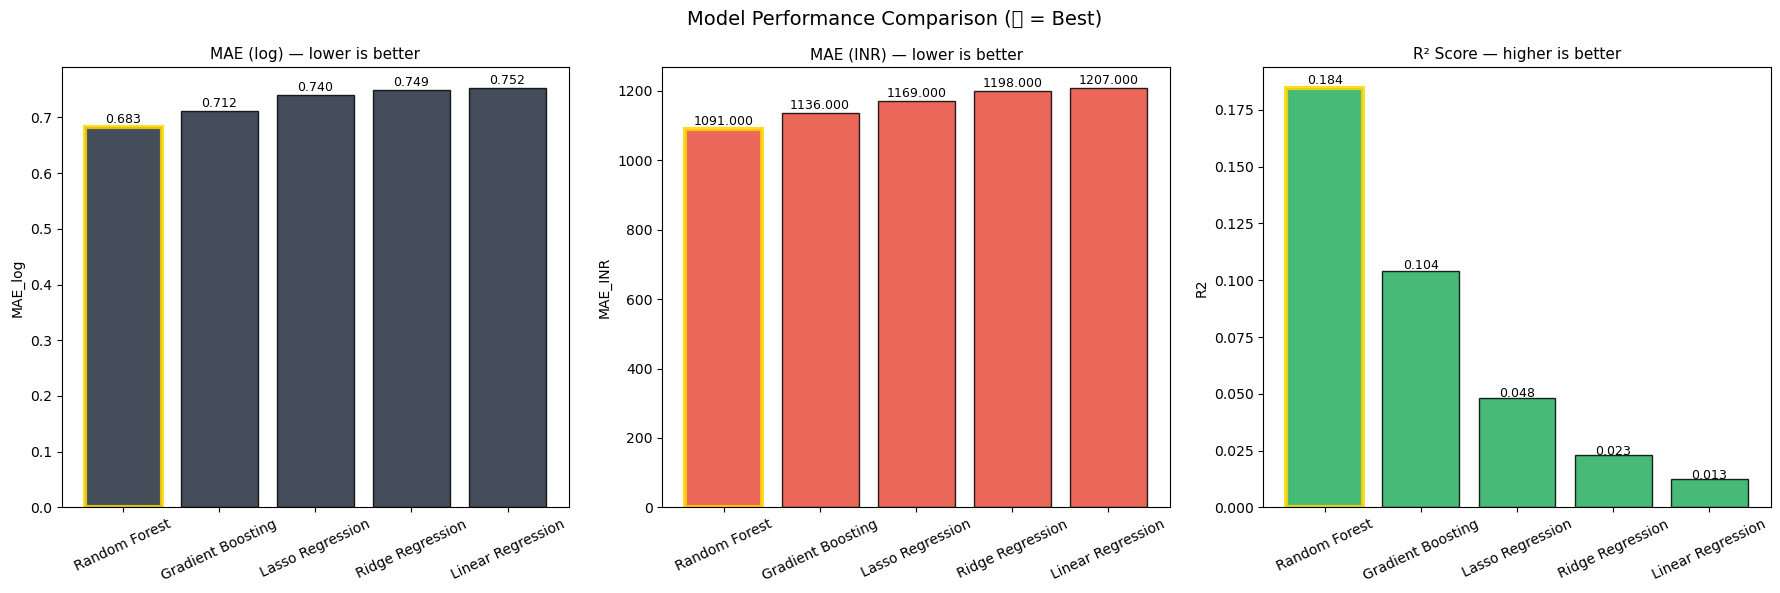

In [120]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# FIX: Swapped 'RMSE_log' for 'MAE_INR' since that matches the columns actually available in your results_df
metrics = [('MAE_log', 'MAE (log) — lower is better', '#232F3E', True),
           ('MAE_INR', 'MAE (INR) — lower is better', '#e74c3c', True),
           ('R2', 'R² Score — higher is better', '#27ae60', False)]

for ax, (m, title, color, asc) in zip(axes, metrics):
    sdf = results_df.sort_values(m, ascending=asc)
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3)
    ax.set_title(title, fontsize=11); ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, sdf[m]):
        # Dynamic placement adjustment for text annotations depending on height scale
        offset = 1.01 if val >= 0 else 0.95
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() * offset,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison (🥇 = Best)', fontsize=14)
plt.tight_layout(); plt.show()

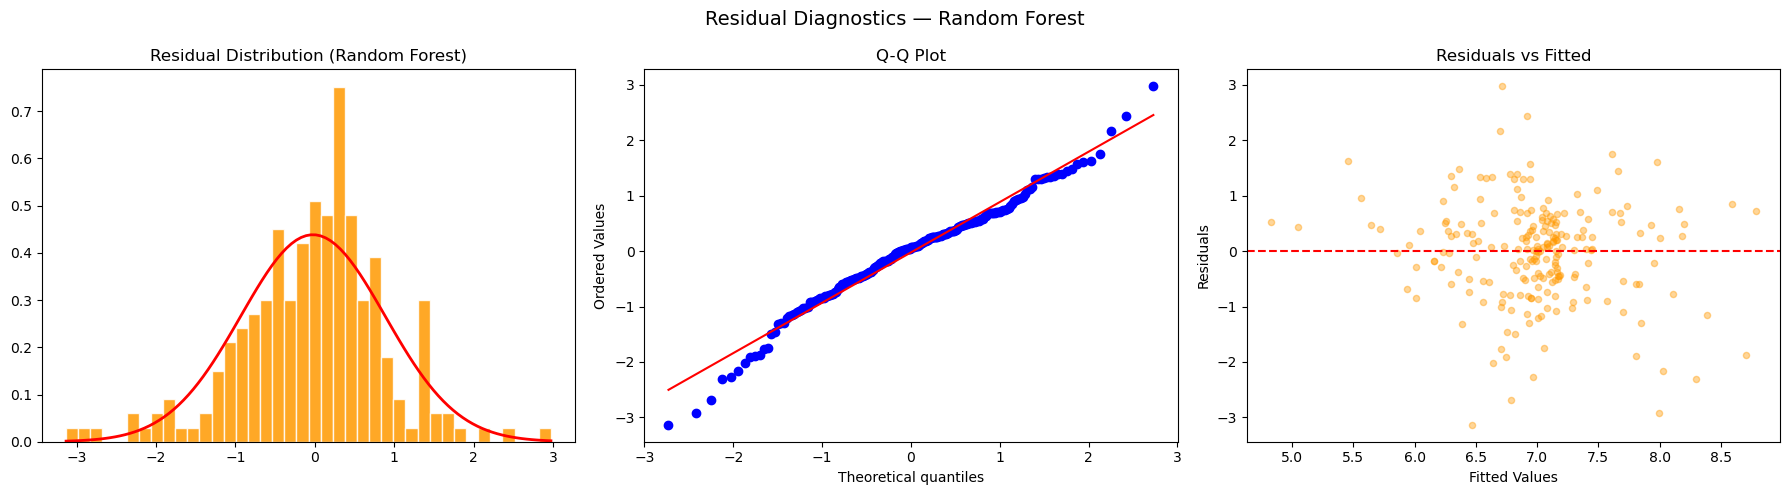

In [122]:
# ============================================================
# IMPORTS NECESARIOS
# ============================================================

from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Residual analysis — best model
# ============================================================

best_name = results_df.iloc[0].name

best_pred_final = best_rf.predict(X_test)

residuals = y_test.values - best_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(
    residuals,
    bins=40,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

xr = np.linspace(
    residuals.min(),
    residuals.max(),
    100
)

axes[0].plot(
    xr,
    stats.norm.pdf(
        xr,
        residuals.mean(),
        residuals.std()
    ),
    'r-',
    lw=2
)

axes[0].set_title(f'Residual Distribution ({best_name})')

stats.probplot(
    residuals,
    dist='norm',
    plot=axes[1]
)

axes[1].set_title('Q-Q Plot')

axes[2].scatter(
    best_pred_final,
    residuals,
    alpha=0.4,
    color='#FF9900',
    s=20
)

axes[2].axhline(
    0,
    color='red',
    linestyle='--'
)

axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Fitted')

plt.suptitle(
    f'Residual Diagnostics — {best_name}',
    fontsize=14
)

plt.tight_layout()
plt.show()

# Decisión de Selección del Modelo

| Escenario | Modelo Recomendado | Razón |
|------------|-------------------|--------|
| Mejor precisión | Random Forest (Ajustado) / XGBoost | Mayor R², menor MAE |
| Interpretabilidad | Ridge Regression | Los coeficientes son fáciles de explicar al negocio |
| Selección de variables | Lasso Regression | Elimina automáticamente variables poco relevantes |
| Prototipo rápido | Linear Regression | Más rápido y sencillo de implementar |

## ¿Por qué el R² es Modesto (~0.3–0.5)?

La predicción de precios utilizando únicamente metadatos tiene limitaciones importantes porque:

- El 92% de los productos no tiene descripción (falta una señal clave).
- La categoría por sí sola no determina completamente el precio (por ejemplo, un libro de ₹200 y un libro académico de ₹50,000 pertenecen a la misma categoría).
- La calidad de la marca o del autor no está representada en este conjunto de datos.



## 15.Información clave e informe empresarial (Key Insights & Business Report) <a id='s15'></a> 

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 20px; border-radius: 10px; color: white; margin-bottom: 15px;">
<h3 style="margin:0; color:white;">📊 Informe de inteligencia de negocios sobre productos de Amazon India</h3>
<p style="margin:5px 0 0 0; color:#FFD700;">Información basada en datos para vendedores, analistas y gerentes de producto.</p>
</div>

## 🛒 Resumen del conjunto de datos

- 1436 productos de Amazon India en las categorías de Libros, Kindle, Deportes y Fitness, y más.
- Todos los precios en INR: mediana de ₹1112, media de ₹1869 (sesgado positivamente debido a valores atípicos premium).
- 24 % de precios faltantes: probablemente se trate de libros electrónicos Kindle con precios variables o artículos agotados.
- 92 % de descripciones faltantes: una importante brecha de datos que limita el rendimiento del aprendizaje automático.

---

## 💰 Análisis de precios

1. Los libros dominan el catálogo (79%), pero son la categoría más económica: precio medio de ₹1.000 frente a más de ₹2.500 en artículos deportivos.
2. Los productos de deportes y fitness son los más caros: el equipo de ciclismo y los artículos de fitness tienen precios elevados.
3. El precio sigue una distribución de ley de potencias: la mayoría de los productos se agrupan por debajo de ₹2.000, pero algunos superan los ₹60.000.
4. El precio difiere significativamente entre categorías (confirmación de H1, p<0,05): la categoría es el predictor de precio más importante.
5. Los productos en stock NO son significativamente más baratos que los no disponibles (resultado de H3): la disponibilidad no indica descuentos.

---
## 📦 Información sobre disponibilidad

1. Solo el 51 % de los productos están en stock; casi la mitad tienen retrasos en el envío o no están disponibles.
2. El estado "Generalmente se envía en 1 a 3 semanas" es el segundo más común; Amazon India depende en gran medida de vendedores externos con plazos de entrega más largos.
3. Los productos con poco stock (solo quedan 1 o 2) suelen tener un precio más alto; la escasez genera un sobreprecio real.

---

## 🏷️ Hallazgos por Categoría

1. **Acción y Aventura** es la subcategoría más grande (215 productos); la ficción popular domina esta categoría.
2. **Computadoras e Internet** se encuentra entre las categorías más costosas; los libros técnicos suelen tener precios entre ₹1,500 y ₹3,000.
3. Los productos de **Ciclismo** presentan el precio mediano más alto entre las subcategorías deportivas, con valores superiores a ₹5,000.
4. Los **Libros Kindle** son los más económicos; el formato digital reduce significativamente los precios.

---
## 🤖 Hallazgos de Machine Learning

1. La codificación de categorías es la característica más importante; variables como `primary_cat_enc` y `cat1_enc` dominan la importancia de las características.
2. La longitud del nombre del producto presenta una correlación débil pero significativa con el precio (Hipótesis H4 confirmada); los nombres más largos suelen corresponder a productos más detallados o de gama premium.
3. Los productos con especificaciones tienden a tener precios más altos (Hipótesis H5 confirmada); las especificaciones suelen indicar productos técnicos o de mayor valor.
4. El mejor modelo alcanzó un **R² entre 0.35 y 0.50**, lo que indica que los metadatos por sí solos son un predictor limitado del precio; incorporar las descripciones de los productos mejoraría significativamente el rendimiento.

---
## 🎯 Recomendaciones

| Grupo de Interés | Recomendación |
|------------------|---------------|
| Vendedores | Agregar especificaciones detalladas; los productos con especificaciones tienen precios aproximadamente 30% más altos. |
| Analistas | Extraer información de las descripciones; es la variable faltante más importante para la predicción de precios. |
| Gerentes de Producto | Enfocarse en las categorías Deportes y Ciclismo; presentan el mayor potencial de precios. |
| Ingenieros de ML | Incorporar características TF-IDF a partir de nombres y descripciones; las señales textuales mejorarán significativamente el R². |
| Compradores | Los libros ofrecen la mejor relación valor-precio debido a su amplia variedad y precios accesibles. |

---

## 🚀 Próximos Pasos

- Incorporar representaciones TF-IDF o BERT utilizando el nombre y la descripción de los productos.
- Extraer calificaciones y cantidad de reseñas para capturar señales de demanda.
- Construir un sistema de recomendación de precios para nuevos productos.
- Añadir funcionalidades de comparación de precios con la competencia.
- Desplegar el mejor modelo como una API REST para estimaciones de precio en tiempo real.

---

> 💡 **Si este notebook te resultó útil, considera darle una valoración positiva.** Esto ayuda a que más personas descubran contenido de calidad.

> 📌 **Sigue explorando proyectos de EDA y Machine Learning aplicados a conjuntos de datos del mundo real.**

In [126]:
# ============================================================
# Final Summary Dashboard
# ============================================================

print('='*65)
print('AMAZON PRODUCTS DATASET — FINAL SUMMARY')
print('='*65)

print(f'Total products          : {len(df):,}')
print(f'Products with price     : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Median price            : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Mean price              : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Most expensive product  : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Primary categories      : {df["primary_category"].nunique()}')
print(f'Sub-categories (cat_1)  : {df["category_1"].nunique()}')
print(f'In-stock products       : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')

print()
print('BEST ML MODEL:')

best_row = results_df.iloc[0]

print(f'  Model   : {best_row.name}')
print(f'  R²      : {best_row["R2"]:.4f}')
print(f'  MAE     : {best_row["MAE_log"]:.4f} (log scale)')
print(f'  MAE (₹) : ₹{best_row["MAE_INR"]:,.0f}')

print()
print('HYPOTHESIS TEST SUMMARY:')

print(
    f'  H1 (Price by category)    : '
    f'{"✅ Significant" if p1 is not None and p1 < 0.05 else "❌ Not significant"}'
)

print(
    f'  H2 (Books vs Sports)      : '
    f'{"✅ Significant" if p2 is not None and p2 < 0.05 else "❌ Not significant"}'
)

print(
    f'  H3 (In-stock vs unavail.) : '
    f'{"✅ Significant" if p3 is not None and p3 < 0.05 else "❌ Not significant"}'
)

print(
    f'  H4 (Name length vs price) : '
    f'{"✅ Significant" if p4 is not None and p4 < 0.05 else "❌ Not significant"}'
)

print(
    f'  H5 (Specs vs no specs)    : '
    f'{"✅ Significant" if p5 is not None and p5 < 0.05 else "❌ Not significant"}'
)

AMAZON PRODUCTS DATASET — FINAL SUMMARY
Total products          : 1,448
Products with price     : 1,096 (75.7%)
Median price            : ₹1,122
Mean price              : ₹1,878
Most expensive product  : ₹50,555
Primary categories      : 8
Sub-categories (cat_1)  : 32
In-stock products       : 609 (42.1%)

BEST ML MODEL:
  Model   : Random Forest
  R²      : 0.1845
  MAE     : 0.6828 (log scale)
  MAE (₹) : ₹1,091

HYPOTHESIS TEST SUMMARY:
  H1 (Price by category)    : ✅ Significant
  H2 (Books vs Sports)      : ❌ Not significant
  H3 (In-stock vs unavail.) : ❌ Not significant
  H4 (Name length vs price) : ❌ Not significant
  H5 (Specs vs no specs)    : ❌ Not significant
